In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# train test split on placement dataset
data = pd.read_csv('placement.csv')
new_data = data.sample(200,ignore_index=True,random_state=42)
test = new_data.iloc[:40].sample(40,ignore_index=True)
train = new_data.iloc[40:].sample(160,ignore_index=True)
train_x = train['cgpa']
train_y = train['package']
test_x = test['cgpa']
test_y = test['package']

In [6]:
w = 0
b = 0
m = train_x.size
def derivative_w(w,b):
    r =( w*train_x + b - train_y)@train_x
    return r/m
def derivative_b(w,b):
    r =( w*train_x + b - train_y)
    r = r.sum()
    return r/m
def gradient_descent(w,b):
    alpha = 0.001;
    while True:
      temp_w = w - alpha*derivative_w(w,b)
      temp_b = b - alpha*derivative_b(w,b)
      if abs(temp_w - w)<0.000001 and abs(temp_b - b)<0.000001:
        break
      else:
        b = temp_b
        w = temp_w
      # return gradient_descent(w,b)
    return w,b

grad = gradient_descent(w,b)
print(grad)


(np.float64(0.5682096519174741), np.float64(-0.983646703852735))


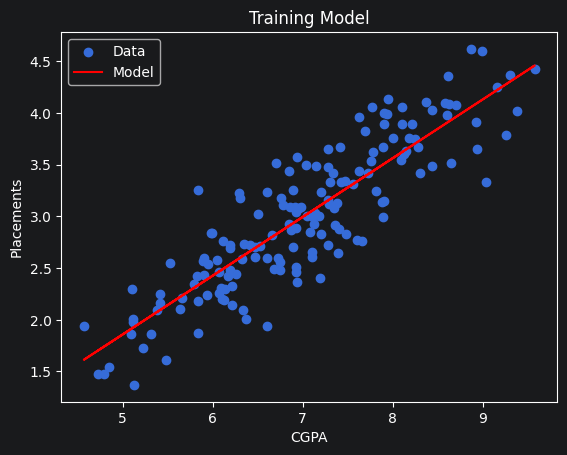

In [7]:
w = grad[0]
b = grad[1]
y = w*train_x + b
plt.title("Training Model")
plt.scatter(train_x,train_y,label='Data')
plt.plot(train_x,y,label='Model',color='r')
plt.xlabel("CGPA")
plt.ylabel("Placements")
plt.legend()

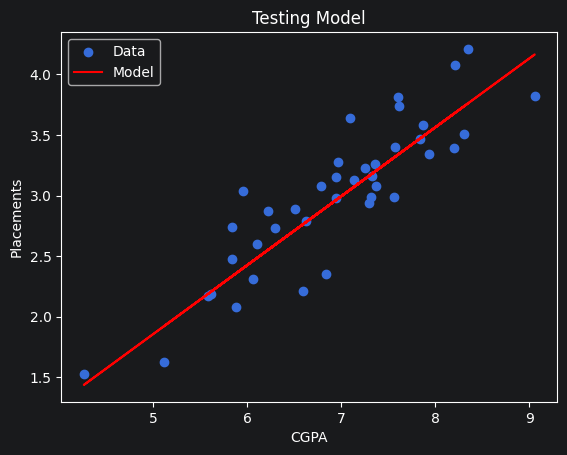

In [8]:
y = w*test_x + b
plt.title('Testing Model')
plt.scatter(test_x,test_y,label='Data')
plt.plot(test_x,y,label='Model',color='r')
plt.xlabel("CGPA")
plt.ylabel("Placements")
plt.legend()

In [9]:
train_size = train_x.size
result = (train_y - w*train_x+b)**2
rmse1 = ((1/train_size)*result.sum())**0.5
rmse1

np.float64(1.9966984889757187)

In [10]:
# testing the model using RMSE
test_size = test_x.size
result = (test_y - w*test_x+b)**2
rmse = ((1/test_size)*result.sum())**0.5
rmse

np.float64(1.9463439279317183)

In [11]:
SSr =( ((test_y+train_y) - (w*(test_x+train_x)+b))**2).sum()
SSm = (((test_y+train_y) - ((test_y+train_y).mean()))**2).sum()
r2 = 1 -( SSr/SSm)
r2
SSr =( (test_y - (w*test_x+b))**2).sum()
SSm = ((test_y - (test_y.mean()))**2).sum()
r2 = 1 -( SSr/SSm)
r2

np.float64(0.7741196355520408)